## Clase 02 — Del Insight a los Datos

##### Análisis descriptivo, diagnóstico y predictivo
##### Ciclo Magistral · Inteligencia de Datos: Análisis e IA Aplicada · 2026
###### Mara Destefanis · Mgter. Ciencia de Datos · Lic. Comunicación Social

### NOTEBOOK: 02_descriptivo_diagnostico.ipynb ────────────────────────────────
>##### Propósito: análisis descriptivo y diagnóstico del mercado de paltas
>##### Output   : gráficos interactivos Plotly + tablas resumen para el >#### tablero


## Preguntas que responden los gráficos

**Bloque descriptivo — ¿qué pasó y cuánto?**

- **G1 · Volumen semanal total** → ¿Cómo evolucionó la demanda de paltas semana a semana a lo largo del período? ¿Hay tendencia creciente, estable o con caídas?
- **G2 · Volumen por tamaño** → ¿Qué calibre de palta concentra el mayor volumen de ventas? ¿El mercado prefiere la palta normal, grande o extra grande?
- **G3 · Área apilada por tipo** → ¿Qué proporción del mercado corresponde a palta convencional vs. orgánica? ¿Creció la participación orgánica con el tiempo?

**Bloque diagnóstico — ¿dónde, cuándo y por qué?**

- **G4 · Estacionalidad mensual** → ¿Hay meses del año con picos consistentes de demanda? ¿La estacionalidad es igual para palta convencional y orgánica?
- **G5 · Regiones con más ventas** → ¿Qué mercados regionales concentran el mayor volumen? ¿Difiere el perfil convencional/orgánico entre regiones?
- **G6 · Mapa de volumen** → ¿Cómo se distribuye geográficamente la demanda en EEUU? ¿Hay concentración en la costa oeste o es un mercado distribuido?

### 0. Set up

In [17]:
# Preliminares 

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy  as np
from pathlib import Path

# Visualización — Plotly como principal
import plotly.express       as px
import plotly.graph_objects as go
from plotly.subplots        import make_subplots

# Matplotlib/Seaborn solo si hace falta algún fallback puntual
import matplotlib.pyplot as plt
import seaborn           as sns

from IPython.display import display, HTML

# ── Paleta personalizada ──────────────────────────────────────────────────────
PALETA = {
    "hueso":   "#F2EFE4",
    "oliva":   "#7C8C5E",
    "tierra":  "#A0785A",
    "musgo":   "#4F6347",
    "pizarra": "#5A6472",
    "crema":   "#D9D2C0",
    "ink":     "#2C2C2C",
}

COLORES_SEQ = [
    PALETA["oliva"],
    PALETA["tierra"],
    PALETA["pizarra"],
    PALETA["musgo"],
    PALETA["crema"],
]

# Template Plotly con la identidad visual del proyecto
TEMPLATE_PALTA = go.layout.Template(
    layout=go.Layout(
        font       = dict(family="Georgia, serif", color=PALETA["ink"], size=12),
        paper_bgcolor = "white",
        plot_bgcolor  = "white",
        title      = dict(font=dict(size=14, color=PALETA["ink"]), x=0.5, xanchor="center"),
        xaxis      = dict(
            showgrid=False,
            linecolor=PALETA["ink"],
            linewidth=0.7,
            tickfont=dict(size=10),
        ),
        yaxis      = dict(
            gridcolor=PALETA["crema"],
            gridwidth=0.5,
            linecolor=PALETA["ink"],
            linewidth=0.7,
            tickfont=dict(size=10),
        ),
        legend     = dict(
            bgcolor="rgba(0,0,0,0)",
            borderwidth=0,
            font=dict(size=10),
        ),
        colorway   = COLORES_SEQ,
    )
)

# Registrar el template para usarlo por nombre
import plotly.io as pio
pio.templates["palta"] = TEMPLATE_PALTA
pio.templates.default  = "palta"

# ── Display numérico ──────────────────────────────────────────────────────────
pd.set_option("display.max_columns",  None)
pd.set_option("display.float_format", "{:,.2f}".format)

print(f"Template Plotly: activo — 'palta'")

Template Plotly: activo — 'palta'


#### 1- DATOS

In [20]:
# ── Carga de datos ────────────────────────────────────────────────────────────
DATA_PATH = Path(r"C:\Users\ASUS\Documents\Teacher\Clases_Magistrales\sesion2_Delosdatos-al-insight\Datos\palta_1.csv")

palta_1 = pd.read_csv(DATA_PATH)

print(f"Dataset cargado: {palta_1.shape[0]:,} filas · {palta_1.shape[1]} columnas")

display(palta_1.info())

Dataset cargado: 52,483 filas · 9 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52483 entries, 0 to 52482
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Fecha              52483 non-null  object 
 1   PrecioPromedio     52483 non-null  float64
 2   TotalVolume        52483 non-null  float64
 3   Palta_Normal       52483 non-null  float64
 4   Palta_Grande       52483 non-null  float64
 5   Palta_Extragrande  52483 non-null  float64
 6   TotalBags          52483 non-null  float64
 7   Tipo               52483 non-null  object 
 8   Region_Geo         52483 non-null  object 
dtypes: float64(6), object(3)
memory usage: 3.6+ MB


None

In [26]:
# Formato 

palta_1[['Tipo','Region_Geo']] =palta_1[['Tipo','Region_Geo']].astype('category')
palta_1['Fecha'] = pd.to_datetime(palta_1["Fecha"])

### 3 BLOQUE 1 — DESCRIPTIVO

- Línea de tiempo — volumen semanal total
- Barras horizontales — volumen por tamaño de palta
- Área apilada — volumen por tipo (orgánico vs convencional) en el tiempo

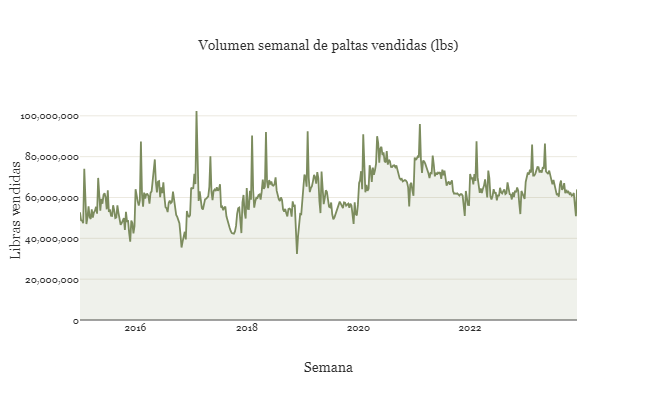

In [28]:
# ── GRÁFICO 1: Volumen semanal total ─────────────────────────────────────────
# Agregamos por semana sumando todas las regiones

vol_semanal = (
    palta_1
    .groupby("Fecha")["TotalVolume"]
    .sum()
    .reset_index()
    .sort_values("Fecha")
)

fig1 = go.Figure()

fig1.add_trace(go.Scatter(
    x    = vol_semanal["Fecha"],
    y    = vol_semanal["TotalVolume"],
    mode = "lines",
    name = "Volumen total",
    line = dict(color=PALETA["oliva"], width=1.8),
    fill = "tozeroy",
    fillcolor = "rgba(124, 140, 94, 0.12)",  # oliva muy transparente
))

fig1.update_layout(
    title    = "Volumen semanal de paltas vendidas (lbs)",
    xaxis_title = "Semana",
    yaxis_title = "Libras vendidas",
    yaxis = dict(tickformat=",.0f"),
    height = 400,
)

fig1.show()

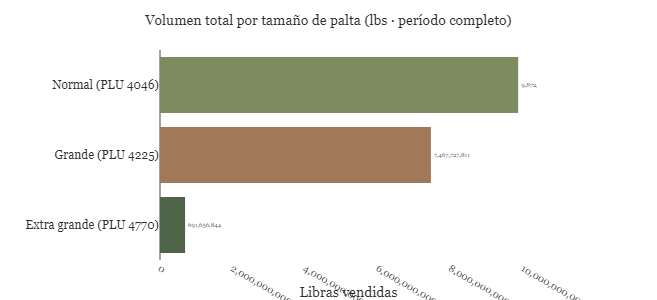

In [34]:
# ── GRÁFICO 2: Volumen por tamaño de palta ───────────────────────────────────
# Suma total del período completo por cada tamaño

vol_tamanio = pd.DataFrame({
    "Tamaño": ["Normal (PLU 4046)", "Grande (PLU 4225)", "Extra grande (PLU 4770)"],
    "Volumen": [
        palta_1["Palta_Normal"].sum(),
        palta_1["Palta_Grande"].sum(),
        palta_1["Palta_Extragrande"].sum(),
    ]
}).sort_values("Volumen")  # ascending para que el mayor quede arriba en horizontal

fig2 = go.Figure()

fig2.add_trace(go.Bar(
    x           = vol_tamanio["Volumen"],
    y           = vol_tamanio["Tamaño"],
    orientation = "h",
    marker_color = [PALETA["musgo"], PALETA["tierra"], PALETA["oliva"]],
    text         = vol_tamanio["Volumen"].apply(lambda x: f"{x:,.0f}"),
    textposition = "outside",
    textfont     = dict(size=6),
))

fig2.update_layout(
    title       = "Volumen total por tamaño de palta (lbs · período completo)",
    xaxis_title = "Libras vendidas",
    yaxis_title = "",
    xaxis       = dict(tickformat=",.0f"),
    height      = 300,
    margin      = dict(l=160, r=120, t=50, b=40),  # l para etiquetas Y, r para texto outside
    yaxis       = dict(tickfont=dict(size=12)),      # etiquetas de barra más grandes
)


fig2.show()

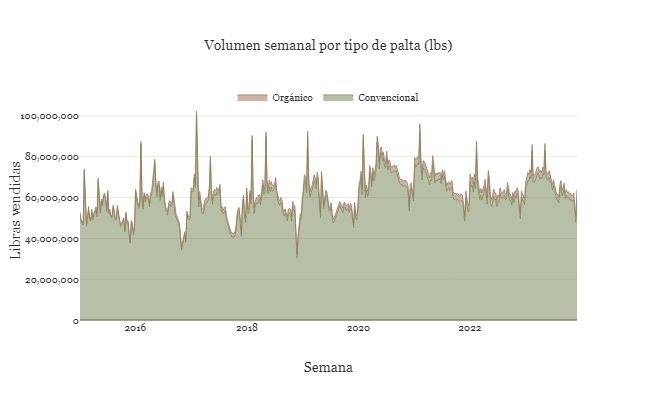

In [36]:
# ── GRÁFICO 3: Área apilada — volumen por tipo (orgánico vs convencional) ────
# Agregamos por semana y tipo

vol_tipo = (
    palta_1
    .groupby(["Fecha", "Tipo"])["TotalVolume"]
    .sum()
    .reset_index()
    .sort_values("Fecha")
)

convencional = vol_tipo[vol_tipo["Tipo"] == "conventional"]
organico     = vol_tipo[vol_tipo["Tipo"] == "organic"]

fig3 = go.Figure()

fig3.add_trace(go.Scatter(
    x         = convencional["Fecha"],
    y         = convencional["TotalVolume"],
    name      = "Convencional",
    mode      = "lines",
    stackgroup = "one",
    line      = dict(color=PALETA["oliva"], width=0.8),
    fillcolor = "rgba(124, 140, 94, 0.55)",
))

fig3.add_trace(go.Scatter(
    x         = organico["Fecha"],
    y         = organico["TotalVolume"],
    name      = "Orgánico",
    mode      = "lines",
    stackgroup = "one",
    line      = dict(color=PALETA["tierra"], width=0.8),
    fillcolor = "rgba(160, 120, 90, 0.55)",
))

fig3.update_layout(
    title       = "Volumen semanal por tipo de palta (lbs)",
    xaxis_title = "Semana",
    yaxis_title = "Libras vendidas",
    yaxis       = dict(tickformat=",.0f"),
    height      = 400,
    legend      = dict(orientation="h", y=1.08, x=0.5, xanchor="center"),
)

fig3.show()

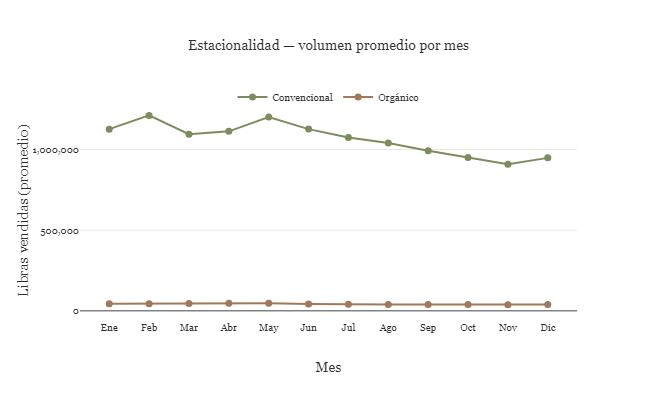

In [39]:
# ── GRÁFICO 4: Estacionalidad — volumen por mes ───────────────────────────────
# Promedio mensual para ver patrones que se repiten año a año

MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
         "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

estacionalidad = (
    palta_1
    .groupby([palta_1["Fecha"].dt.month, "Tipo"])["TotalVolume"]
    .mean()
    .reset_index()
    .rename(columns={"Fecha": "Mes"})
)
estacionalidad["Mes_nombre"] = estacionalidad["Mes"].apply(lambda x: MESES[x-1])

convencional_e = estacionalidad[estacionalidad["Tipo"] == "conventional"]
organico_e     = estacionalidad[estacionalidad["Tipo"] == "organic"]

fig4 = go.Figure()

fig4.add_trace(go.Scatter(
    x    = convencional_e["Mes_nombre"],
    y    = convencional_e["TotalVolume"],
    name = "Convencional",
    mode = "lines+markers",
    line = dict(color=PALETA["oliva"], width=2),
    marker = dict(size=7, color=PALETA["oliva"]),
))

fig4.add_trace(go.Scatter(
    x    = organico_e["Mes_nombre"],
    y    = organico_e["TotalVolume"],
    name = "Orgánico",
    mode = "lines+markers",
    line = dict(color=PALETA["tierra"], width=2),
    marker = dict(size=7, color=PALETA["tierra"]),
))

fig4.update_layout(
    title       = "Estacionalidad — volumen promedio por mes",
    xaxis_title = "Mes",
    yaxis_title = "Libras vendidas (promedio)",
    yaxis       = dict(tickformat=",.0f"),
    height      = 400,
    legend      = dict(orientation="h", y=1.08, x=0.5, xanchor="center"),
    xaxis       = dict(categoryorder="array", categoryarray=MESES),
)

fig4.show()

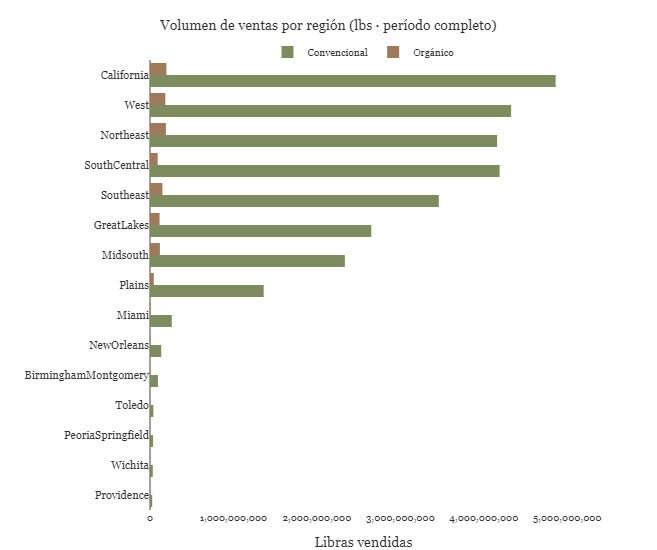

In [41]:
# ── GRÁFICO 5: Regiones con más ventas por tipo ───────────────────────────────

vol_region = (
    palta_1
    .groupby(["Region_Geo", "Tipo"])["TotalVolume"]
    .sum()
    .reset_index()
)

# Ordenar por volumen total descendente
orden = (
    vol_region
    .groupby("Region_Geo")["TotalVolume"]
    .sum()
    .sort_values()
    .index
)

convencional_r = vol_region[vol_region["Tipo"] == "conventional"]
organico_r     = vol_region[vol_region["Tipo"] == "organic"]

fig5 = go.Figure()

fig5.add_trace(go.Bar(
    x            = convencional_r["TotalVolume"],
    y            = convencional_r["Region_Geo"],
    orientation  = "h",
    name         = "Convencional",
    marker_color = PALETA["oliva"],
))

fig5.add_trace(go.Bar(
    x            = organico_r["TotalVolume"],
    y            = organico_r["Region_Geo"],
    orientation  = "h",
    name         = "Orgánico",
    marker_color = PALETA["tierra"],
))

fig5.update_layout(
    title       = "Volumen de ventas por región (lbs · período completo)",
    xaxis_title = "Libras vendidas",
    yaxis_title = "",
    barmode     = "group",
    height      = 550,
    yaxis       = dict(categoryorder="array", categoryarray=list(orden),
                       tickfont=dict(size=11)),
    xaxis       = dict(tickformat=",.0f"),
    legend      = dict(orientation="h", y=1.05, x=0.5, xanchor="center"),
    margin      = dict(l=150, r=80, t=60, b=40),
)

fig5.show()

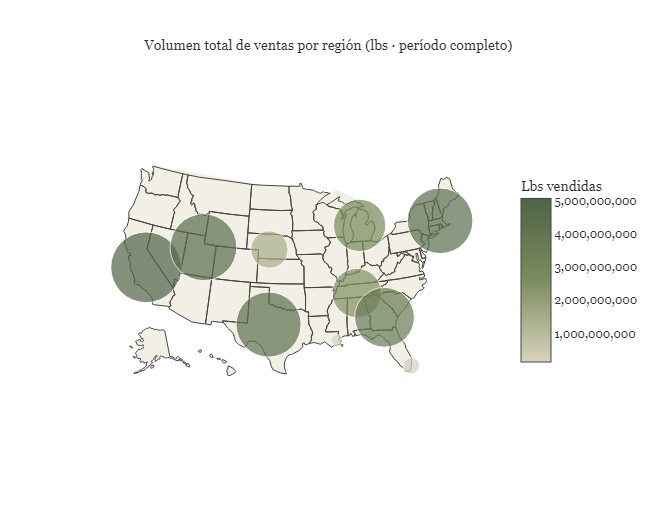

In [43]:
# ── GRÁFICO 6: Mapa — volumen por región ─────────────────────────────────────
# Coordenadas aproximadas por región de mercado HAB

COORDS_REGION = {
    "California":        (36.7783, -119.4179),
    "West":              (40.5865, -111.0937),
    "Plains":            (41.1254, -100.2678),
    "SouthCentral":      (31.9686, -99.9018),
    "Southeast":         (32.1656, -82.9001),
    "Midsouth":          (35.5175, -86.5804),
    "Northeast":         (42.4072, -71.3824),
    "GreatLakes":        (43.6961, -84.9553),
    "NewYork":           (40.7128, -74.0060),
    "LosAngeles":        (34.0522, -118.2437),
    "Chicago":           (41.8781, -87.6298),
    "Houston":           (29.7604, -95.3698),
    "Atlanta":           (33.7490, -84.3880),
    "DallasFtWorth":     (32.7767, -96.7970),
    "Seattle":           (47.6062, -122.3321),
    "Portland":          (45.5051, -122.6750),
    "Denver":            (39.7392, -104.9903),
    "PhoenixTucson":     (33.4484, -112.0740),
    "LasVegas":          (36.1699, -115.1398),
    "SanDiego":          (32.7157, -117.1611),
    "SanFrancisco":      (37.7749, -122.4194),
    "Sacramento":        (38.5816, -121.4944),
    "Spokane":           (47.6588, -117.4260),
    "Boise":             (43.6150, -116.2023),
    "RaleighGreensboro": (35.7796, -78.6382),
    "Charlotte":         (35.2271, -80.8431),
    "Richmond":          (37.5407, -77.4360),
    "Philadelphia":      (39.9526, -75.1652),
    "Boston":            (42.3601, -71.0589),
    "Pittsburgh":        (40.4406, -79.9959),
    "Columbus":          (39.9612, -82.9988),
    "Cincinnati":        (39.1031, -84.5120),
    "Detroit":           (42.3314, -83.0458),
    "Indianapolis":      (39.7684, -86.1581),
    "Louisville":        (38.2527, -85.7585),
    "Nashville":         (36.1627, -86.7816),
    "NewOrleans":        (29.9511, -90.0715),
    "Tampa":             (27.9506, -82.4572),
    "Orlando":           (28.5383, -81.3792),
    "Miami":             (25.7617, -80.1918),
    "Jacksonville":      (30.3322, -81.6557),
    "BuffaloRochester":  (42.8864, -78.8784),
    "Albany":            (42.6526, -73.7562),
    "Hartford":          (41.7658, -72.6851),
    "GrandRapids":       (42.9634, -85.6681),
    "StLouis":           (38.6270, -90.1994),
    "KansasCity":        (39.0997, -94.5786),
    "Minneapolis":       (44.9778, -93.2650),
    "Milwaukee":         (43.0389, -87.9065),
    "Omaha":             (41.2565, -95.9345),
    "WestTexCapRock":    (31.5493, -102.5780),
    "NorthernNewEngland":(44.3148, -72.9981),
    "SouthCarolina":     (33.8361, -81.1637),
    "Tennessee":         (35.8601, -86.6602),
}

# Volumen total por región (ambos tipos sumados)
vol_mapa = (
    palta_1
    .groupby("Region_Geo")["TotalVolume"]
    .sum()
    .reset_index()
)

# Agregar coordenadas
vol_mapa["lat"] = vol_mapa["Region_Geo"].map(lambda r: COORDS_REGION.get(r, (None, None))[0])
vol_mapa["lon"] = vol_mapa["Region_Geo"].map(lambda r: COORDS_REGION.get(r, (None, None))[1])
vol_mapa = vol_mapa.dropna(subset=["lat", "lon"])

fig6 = px.scatter_geo(
    vol_mapa,
    lat           = "lat",
    lon           = "lon",
    size          = "TotalVolume",
    hover_name    = "Region_Geo",
    hover_data    = {"TotalVolume": ":,.0f", "lat": False, "lon": False},
    color         = "TotalVolume",
    color_continuous_scale = [
        PALETA["crema"],
        PALETA["oliva"],
        PALETA["musgo"],
    ],
    scope         = "usa",
    title         = "Volumen total de ventas por región (lbs · período completo)",
    size_max      = 50,
)

fig6.update_layout(
    height = 520,
    coloraxis_colorbar = dict(
        title      = "Lbs vendidas",
        tickformat = ",.0f",
        len        = 0.6,
    ),
    geo = dict(
        bgcolor    = "white",
        lakecolor  = PALETA["hueso"],
        landcolor  = PALETA["hueso"],
        showlakes  = True,
        showland   = True,
    ),
)

fig6.show()

In [44]:
fig1.write_html("visual/g1_volumen_semanal.html")
fig2.write_html("visual/g2_volumen_tamanio.html")
fig3.write_html("visual/g3_area_tipo.html")
fig4.write_html("visual/g4_estacionalidad.html")
fig5.write_html("visual/g5_regiones.html")
fig6.write_html("visual/g6_mapa.html")

print("Gráficos exportados.")

Gráficos exportados.
